## Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [7]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [9]:
from langchain_openai import ChatOpenAI
llm_openai = ChatOpenAI(model = "gpt-4o")

In [10]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

### Creating Memory Saver

In [14]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

### Creating Nodes

In [12]:
def superbot(state: State):
    return {"messages" : [llm_groq.invoke(state['messages'])]}

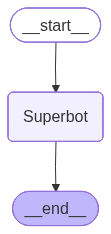

In [15]:
graph = StateGraph(State)

## Node
graph.add_node("Superbot", superbot)

## Edges
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer= memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [19]:
## Specify the thread
config = {"configurable" : {"thread_id" : "1"}} 


## Invocation
graph_builder.invoke({"messages" : "Hi, My name is Luis and I like soccer"}, config=config)

{'messages': [HumanMessage(content='Hi, My name is Luis and I like soccer', additional_kwargs={}, response_metadata={}, id='5e827744-7a41-4ace-85c5-6219c46f7ed1'),
  AIMessage(content="Hi Luis! Nice to meet you! 🤝 I love that you're into soccer—it's such an amazing sport. Do you play any specific position, or are you more of a fan watching it? Also, do you have a favorite team or player? Let me know if you'd like to chat more about matches, strategies, or even cool highlights! ⚽", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 18, 'total_tokens': 183, 'completion_time': 0.407926137, 'completion_tokens_details': {'reasoning_tokens': 85}, 'prompt_time': 0.000670818, 'prompt_tokens_details': None, 'queue_time': 0.070952612, 'total_time': 0.408596955}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd1

## Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results

Aditional parameters in streaming modes for graph state:

- values: This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of the graph after each node is called.

### Streaming The Responses with Stream Method

In [20]:
# Create a  thred
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages" : "Hi, My name is Luis and I like soccer"}, config = config, stream_mode = "updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Hi Luis! Nice to meet you! 🎉 I'm glad to hear you like soccer—it's such an exciting game! Do you follow any particular teams or players? Or maybe you play yourself? I'd love to hear more about what draws you to the sport! ⚽", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 274, 'prompt_tokens': 18, 'total_tokens': 292, 'completion_time': 0.719180824, 'completion_tokens_details': {'reasoning_tokens': 212}, 'prompt_time': 0.000769776, 'prompt_tokens_details': None, 'queue_time': 0.072132747, 'total_time': 0.7199506}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd129-fbb3-7f43-9e2f-e832de22a5ea-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 274, 'total_tokens': 292, 'output_token_details': {'reasoning': 212}})]}}


In [ ]:
for chunk in graph_builder.stream({"messages" : "Hi, My name is Luis and I like soccer"}, config = config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Luis and I like soccer', additional_kwargs={}, response_metadata={}, id='7a1321d5-da0e-44fa-9fda-38926f6d043b'), AIMessage(content="Hi Luis! Nice to meet you! 🎉 I'm glad to hear you like soccer—it's such an exciting game! Do you follow any particular teams or players? Or maybe you play yourself? I'd love to hear more about what draws you to the sport! ⚽", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 274, 'prompt_tokens': 18, 'total_tokens': 292, 'completion_time': 0.719180824, 'completion_tokens_details': {'reasoning_tokens': 212}, 'prompt_time': 0.000769776, 'prompt_tokens_details': None, 'queue_time': 0.072132747, 'total_time': 0.7199506}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd129-fbb3-7f43-9e2f-e832de22a5ea-0', tool_calls=[], invalid_tool_calls=[], usage

In [22]:
for chunk in graph_builder.stream({"messages" : "I also like baseball"}, config = config, stream_mode = "updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='That’s awesome, Luis! 🎉 Having a passion for both soccer and baseball means you’re a fan of two of the most iconic sports—each with its own unique energy! Do you have a favorite baseball team or player? Or do you play either sport yourself? I’d love to hear more about how you got into them! ⚾✨', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 341, 'prompt_tokens': 192, 'total_tokens': 533, 'completion_time': 0.819384749, 'completion_tokens_details': {'reasoning_tokens': 265}, 'prompt_time': 0.007664295, 'prompt_tokens_details': None, 'queue_time': 0.171510427, 'total_time': 0.827049044}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd12c-b281-78c1-9e90-949a46afda1c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 192, 'output_tokens': 341, 'total_to

In [23]:
for chunk in graph_builder.stream({"messages" : "I love running"}, config = config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Luis and I like soccer', additional_kwargs={}, response_metadata={}, id='7a1321d5-da0e-44fa-9fda-38926f6d043b'), AIMessage(content="Hi Luis! Nice to meet you! 🎉 I'm glad to hear you like soccer—it's such an exciting game! Do you follow any particular teams or players? Or maybe you play yourself? I'd love to hear more about what draws you to the sport! ⚽", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 274, 'prompt_tokens': 18, 'total_tokens': 292, 'completion_time': 0.719180824, 'completion_tokens_details': {'reasoning_tokens': 212}, 'prompt_time': 0.000769776, 'prompt_tokens_details': None, 'queue_time': 0.072132747, 'total_time': 0.7199506}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cd129-fbb3-7f43-9e2f-e832de22a5ea-0', tool_calls=[], invalid_tool_calls=[], usage

## Streaming The Responses with astream Method

Steaming tokens we often want to stream more than graph state.

In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of the event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [25]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages": ["Hi my name is Luis and I like soccer"]}, config= config, version = "v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi my name is Luis and I like soccer']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019cd5d8-96d3-7752-ac63-4435c757049c', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is Luis and I like soccer', additional_kwargs={}, response_metadata={}, id='b11757de-3dc8-47bf-b908-1b7a32898cd0'), AIMessage(content="Hi Luis! Nice to meet you. Soccer is awesome—I'd love to hear more about what you enjoy most about it. Do you play any position, or follow a particular team?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 128, 'prompt_tokens': 17, 'total_tokens': 145, 'completion_time': 0.322005478, 'completion_tokens_details': {'reasoning_tokens': 87}, 'prompt_time': 0.000496592, 'prompt_tokens_details': None, 'queue_time': 0.171363967, 'total_time': 0.32250207}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint